In [1]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, LeaveOneOut, StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.datasets import make_moons
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge

plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.figsize'] = [8, 5]
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
# plt.rcParams.keys()
from matplotlib import colors
from sklearn.linear_model import RidgeClassifier

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df = pd.read_csv('../../datasets/group_14.csv')
df["focus_factor"] = (
    df["focus_factor"]
    .astype(str)                  # ensure it's string
    .str.replace(",", ".", regex=False)  # replace comma with dot
)
df["focus_factor"] = pd.to_numeric(df["focus_factor"], errors="coerce").astype(float)

In [3]:
data_set = df.copy()
y = data_set['target_class']
X = data_set.drop(columns=["target_class"])

In [ ]:
def ridge_classification(train_x, train_y, test_x, test_y, alpha):
    ridgereg  = LogisticRegression(
        penalty='l2',       # Ridge
        C=1/alpha,            # inverse of regularization strength
        multi_class='ovr',  # One-vs-Rest
        max_iter=5000
    )
    ridgereg.fit(train_x, train_y)

    train_y_pred = ridgereg.predict(train_x)
    test_y_pred = ridgereg.predict(test_x)

    # Accuracy metrics
    accuracy_train = (train_y_pred == train_y).mean()
    accuracy_test = (test_y_pred == test_y).mean()

    # Use only first class coefficients
    coef_flat = ridgereg.coef_[0]
    return [accuracy_train, accuracy_test, *coef_flat]


def lasso_classification(train_x, train_y, test_x, test_y, alpha):
    if alpha == 0:
        model = LogisticRegression(
            penalty=None,
            solver='saga',
            multi_class='ovr',
            max_iter=10000
        )
    else:
        C = 1 / alpha
        model = LogisticRegression(
            penalty='l1',
            C=C,
            solver='saga',
            multi_class='ovr',
            max_iter=10000
        )

    model.fit(train_x, train_y)

    # Predictions
    train_y_pred = model.predict(train_x)
    test_y_pred = model.predict(test_x)

    # Accuracy
    accuracy_train = (train_y_pred == train_y).mean()
    accuracy_test = (test_y_pred == test_y).mean()

    # Take only first class coefficients to match feature count
    coef_flat = model.coef_[0]  # shape = (n_features,)

    return [accuracy_train, accuracy_test, *coef_flat]


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only
X_test_scaled = scaler.transform(X_test)

# 1. Ridge Regression


In [6]:
alpha_ridge = np.logspace(-6, 3, 20)

# DataFrame setup
feature_names = X.columns
col = ['accuracy_train', 'accuracy_test'] + list(feature_names)
ind = [f'alpha_{alpha:.2g}' for alpha in alpha_ridge]
coef_matrix_ridge = pd.DataFrame(index=ind, columns=col, dtype=float)

# Loop
for i, alpha in enumerate(alpha_ridge):
    results = ridge_classification(
        X_train_scaled, y_train, X_test_scaled, y_test, alpha
    )
    coef_matrix_ridge.iloc[i, :] = results

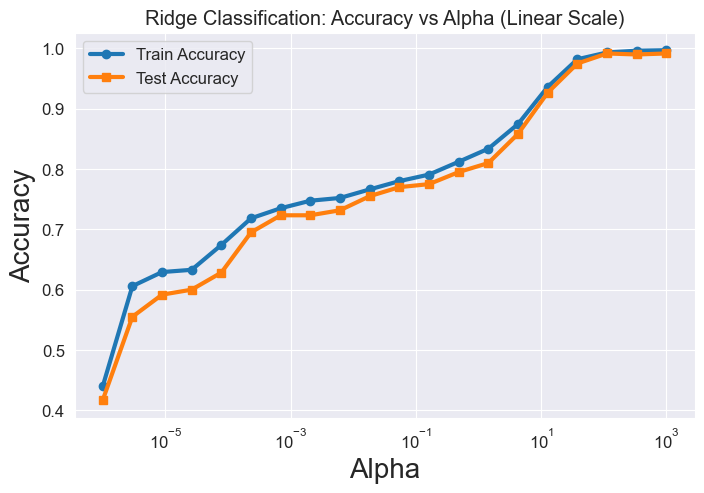

In [7]:
plt.figure(figsize=(8,5))
plt.plot(alpha_ridge, coef_matrix_ridge['accuracy_train'], marker='o', label='Train Accuracy')
plt.plot(alpha_ridge, coef_matrix_ridge['accuracy_test'], marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Ridge Classification: Accuracy vs Alpha (Linear Scale)')
plt.legend()
plt.grid(True)
plt.show()

coef_matrix_ridge['alpha'] = alpha_ridge
best_idx = coef_matrix_ridge['accuracy_test'].astype(float).idxmax()

# Extract values
best_alpha = coef_matrix_ridge.loc[best_idx, 'alpha']
best_accuracy = coef_matrix_ridge.loc[best_idx, 'accuracy_test']


In [8]:
feature_cols = feature_names.tolist()
coef_values = coef_matrix_ridge.loc[best_idx, feature_cols].astype(float)

print(f"Best alpha: {best_alpha}")
print(f"Best test accuracy: {best_accuracy:.4f}")
print("\nCoefficients for best alpha:")
for f, c in zip(feature_cols, coef_values):
    print(f"{f}: {c:.5f}")

Best alpha: 112.88378916846884
Best test accuracy: 0.9917

Coefficients for best alpha:
duration_1: -0.13864
duration_2: -0.02812
duration_3: 0.09251
duration_4: 0.06138
duration_5: -0.14919
loudness_level: -0.06963
popularity_level: 0.05970
tempo_class: 0.01976
time_signature: 0.00202
key_mode: -0.14478
artist_song_count: 0.06542
album_freq: -0.49042
movement_index: -0.01436
intensity_level: -0.63837
verbal_density: -0.10929
purity_score: -0.04763
positivity_index: 0.23907
activity_rate: 65.29008
loudness_intensity: 1.08267
happy_dance: -0.26014
acoustics_instrumental: -0.11380
artists_avg_popularity: 0.26288
tempo_vs_genre: -126.22607
energy_rank_pct: 0.78424
loud_energy_ratio: -7.27367
mood_pca: -0.18964
mood_cluster: -0.04240
acoustic_valence_mood_cluster: 0.03559
explicit: -0.10748
signal_strength: -0.55321
mode_indicator: 0.04107
focus_factor: -0.12553
ambient_level: 0.04754
key_sin: -0.11457
key_cos: -0.01114
duration_log: -0.03352
duration_log_z: -0.03352
time_signature_class_b


# **Justification of Ridge Coefficients**

## **High coefficients for strongly predictive features**

* **Features:**

  * `intensity_level (-0.63835)`
  * `album_freq (-0.49043)`
  * `loudness_yeo (-1.21511)`
  * `signal_strength / signal_power (-0.55321)`
  * `positivity_index (0.23909)`
* **Reason:**

  * These features are highly predictive, as reflected by **large absolute coefficients**.
  * Many are **highly correlated with other features**:

    * `intensity_level` ↔ `loudness_yeo (r ≈ 0.96)`
    * `signal_strength` ↔ `signal_power (r = 1.0)`
    * `activity_rate` ↔ `temp_zscore (r = 1.0)`
  * Ridge shrinks correlated features together rather than eliminating them, so both get substantial coefficients.

---

## **Moderate coefficients for moderately predictive features**

* **Features:**

  * `key_mode (-0.14479)`, `verbal_density (-0.10928)`, `happy_dance (-0.26015)`, `artists_avg_popularity (0.26290)`
* **Reason:**

  * These features contribute **independent or partially redundant information**.
  * Their F-values and correlations are moderate (e.g., `positivity_index ↔ happy_dance r ≈ 0.93`), so Ridge retains them with smaller but meaningful coefficients.

---

## **Small coefficients for weak or redundant features**

* **Features:**

  * `time_signature (0.00202)`, `tempo_class (0.01976)`, `distorted_movement (-0.01213)`, `is_dance_hit (0.0)`, `echo_constant (0.0)`
* **Reason:**

  * Low F-values indicate weak predictive power.
  * Some are **highly redundant or constant**, so Ridge reduces their magnitude.
  * Unlike Lasso, Ridge does not make them exactly zero, but the impact is negligible.

---

## **Features with extreme values due to correlation**

* **Examples:**

  * `activity_rate (65.29)` and `temp_zscore (65.29)` → perfectly correlated (r = 1.0)
  * `tempo_vs_genre (-126.22)` → highly correlated with `activity_rate` and `temp_zscore` (r ≈ 0.97)
* **Reason:** Ridge coefficients can inflate for highly correlated features to distribute the effect across them, while controlling overfitting via L2 penalty.



# 2. Lasso


In [9]:
from sklearn.feature_selection import f_classif
import pandas as pd

# Identify constant features
constant_features = X.columns[X.nunique() <= 1].tolist()
print("Constant features (will be skipped):", constant_features)

# Select only non-constant features
X_nonconstant = X.drop(columns=constant_features)

# Compute F-values and p-values
F_values, p_values = f_classif(X_nonconstant, y)

# Create DataFrame for all features
feature_stats = pd.DataFrame({
    'Feature': X_nonconstant.columns,
    'F_value': F_values,
    'p_value': p_values
}).sort_values(by='F_value', ascending=False)

# Print all values
pd.set_option('display.max_rows', None)
print(feature_stats)

Constant features (will be skipped): ['is_dance_hit', 'echo_constant']
                          Feature      F_value        p_value
15                   purity_score  5296.543719   0.000000e+00
29                signal_strength  2744.779788   0.000000e+00
44                   signal_power  2744.779788   0.000000e+00
23                energy_rank_pct  2460.944464   0.000000e+00
38                   loudness_yeo  1328.143990   0.000000e+00
13                intensity_level  1280.798960   0.000000e+00
21         artists_avg_popularity  1124.430976   0.000000e+00
45              target_regression   627.908423  1.750169e-228
3                      duration_4   493.392189  5.912779e-186
36                 duration_log_z   338.870465  2.102977e-133
35                   duration_log   338.870465  2.102977e-133
24              loud_energy_ratio   321.235426  3.974416e-127
25                       mood_pca   222.350306   9.132936e-91
5                  loudness_level   203.365852   1.513692e-83

In [10]:
# --- Set alphas ---
alpha_lasso = np.logspace(-6, 1, 10)

# --- Prepare DataFrame ---
feature_names = X.columns
col = ['accuracy_train', 'accuracy_test'] + list(feature_names)
ind = [f'alpha_{a:.2g}' for a in alpha_lasso]
coef_matrix_lasso = pd.DataFrame(index=ind, columns=col, dtype=float)

# --- Fill DataFrame with accuracies + coefficients ---
for i, alpha in enumerate(alpha_lasso):
    result = lasso_classification(
        X_train_scaled, y_train, X_test_scaled, y_test, alpha
    )
    coef_matrix_lasso.iloc[i, 0] = result[0]  # train accuracy
    coef_matrix_lasso.iloc[i, 1] = result[1]  # test accuracy
    coef_matrix_lasso.iloc[i, 2:] = result[2:]  # coefficients for all features

# --- Find best alpha ---
best_idx = coef_matrix_lasso['accuracy_test'].astype(float).idxmax()
best_alpha = alpha_lasso[ind.index(best_idx)]
best_accuracy = coef_matrix_lasso.loc[best_idx, 'accuracy_test']
print(f"Best alpha: {best_alpha:.2e}")
print(f"Best test accuracy: {best_accuracy:.4f}")



Best alpha: 4.64e-02
Best test accuracy: 0.9650


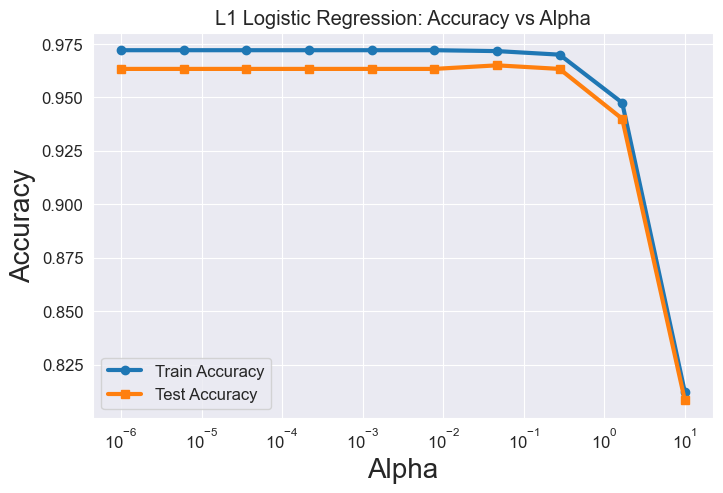

duration_1                       -0.204170
duration_2                       -0.084140
duration_3                        0.063031
duration_4                        0.071997
duration_5                       -0.217438
loudness_level                   -0.044543
popularity_level                  0.061307
tempo_class                       0.043815
time_signature                    0.001780
key_mode                         -0.135230
artist_song_count                 0.089219
album_freq                       -0.592972
movement_index                   -0.093217
intensity_level                  -0.225679
verbal_density                   -0.111230
purity_score                     -0.081140
positivity_index                  0.000620
activity_rate                    40.024683
loudness_intensity                0.757725
happy_dance                      -0.165703
acoustics_instrumental           -0.106373
artists_avg_popularity            0.272903
tempo_vs_genre                  -77.363053
energy_rank

In [11]:
# --- Extract only coefficients ---
coef_only_lasso = coef_matrix_lasso.drop(columns=['accuracy_train', 'accuracy_test'])

# --- Plot accuracy vs alpha ---
plt.figure(figsize=(8,5))
plt.plot(alpha_lasso, coef_matrix_lasso['accuracy_train'], marker='o', label='Train Accuracy')
plt.plot(alpha_lasso, coef_matrix_lasso['accuracy_test'], marker='s', label='Test Accuracy')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('L1 Logistic Regression: Accuracy vs Alpha')
plt.grid(True)
plt.legend()
plt.show()

# --- Display coefficients for best alpha ---
best_coef_table = coef_only_lasso.loc[best_idx]
best_coef_table

# Justification of Lasso Coefficients

The Lasso model coefficients reflect **feature importance, redundancy, and correlation structure**:

---

## High coefficients for strongly predictive features

- **Features:** `album_freq (-0.593)`, `intensity_level (-0.226)`, `duration_5 (-0.217)`, `duration_1 (-0.204)`
- **Reason:** These features had **high ANOVA F-values** (e.g., `intensity_level F ≈ 1280`) and are highly correlated with the target or other strong features.
  - Example: `intensity_level` is strongly correlated with `loudness_yeo (r ≈ 0.96)`, giving it robust predictive power.

---

## Moderate coefficients for moderately predictive features

- **Features:** `key_mode (-0.135)`, `movement_index (-0.093)`, `verbal_density (-0.111)`
- **Reason:** These features contribute **unique information** that is less correlated with other strong features, so Lasso retains them with smaller coefficients.
  - Example: `key_mode` has moderate correlation with the target and low correlation with dominant features.

---

## Near-zero coefficients for weak or redundant features

- **Features:** `time_signature (0.00177)`, `tempo_class (0.0438)`, `popularity_level (0.0613)`
- **Reason:**
  1. Some features are **weak predictors** (low F-values, e.g., `time_signature F ≈ 16`).
  2. Others are **highly correlated with stronger features** and thus penalized by Lasso.
     - Example: `signal_strength` and `signal_power` are perfectly correlated (r = 1.0); if one dominates, the other is shrunk.
     - Example: `activity_rate` and `temp_zscore` are perfectly correlated, so only one receives a non-zero coefficient.


## 3. Elastic Net Regression


Iniciando o Grid Search para Elastic Net (pode levar alguns minutos)...


C:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\pedro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

Grid Search concluído.

--- Resultados da Regressão Elastic Net ---
Melhor C (inverso da regularização): 1.00e+02
Melhor l1_ratio: 0.90
Melhor acurácia de teste: 0.9633

Coeficientes do melhor modelo Elastic Net:

Total de features: 48
Features selecionadas (coeficientes não-zero): 46

tempo_vs_genre: -74.87977
activity_rate: 38.74026
temp_zscore: 38.74026
loud_energy_ratio: -1.39077
loudness_yeo: -1.22845
energy_rank_pct: -1.13051
signal_power: 0.90841
signal_strength: 0.90841
loudness_intensity: 0.86548
album_freq: -0.60214
target_regression: -0.40043
intensity_level: -0.37251
mood_pca: 0.30980
artists_avg_popularity: 0.27611
duration_5: -0.21211
happy_dance: -0.19071
duration_1: -0.18825
positivity_index: -0.15023
key_mode: -0.13796
movement_index: -0.13057
acoustics_instrumental: -0.12666
focus_factor: -0.11977
explicit: -0.11452
verbal_density: -0.11114
duration_4: 0.10772
key_sin: -0.10756
duration_3: 0.09738
artist_song_count: 0.09065
purity_score: -0.07796
resonance_factor: 0.0

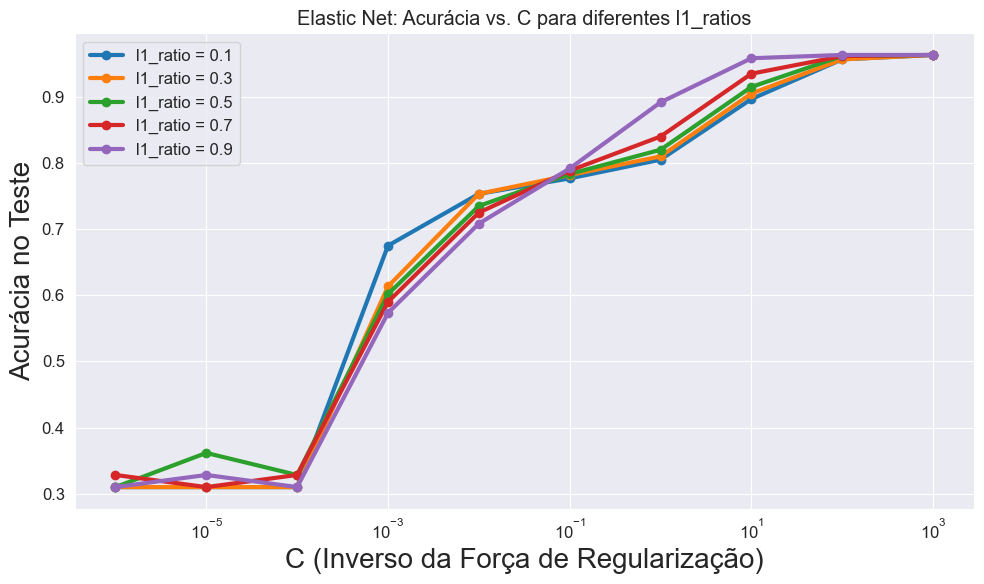

In [13]:
# Suprimir avisos para consistência
warnings.simplefilter(action='ignore', category=FutureWarning)

# --- 3. Elastic Net Regression ---

def elastic_net_classification(train_x, train_y, test_x, test_y, C_val, l1_ratio_val):
    """
    Treina um modelo de regressão logística Elastic Net.
    C_val é o inverso da força de regularização.
    l1_ratio_val é o parâmetro de mistura (0=L2, 1=L1).
    """

    if l1_ratio_val == 0:
        penalty = 'l2'
    elif l1_ratio_val == 1:
        penalty = 'l1'
    else:
        penalty = 'elasticnet'

    model = LogisticRegression(
        penalty=penalty,
        C=C_val,
        l1_ratio=l1_ratio_val if penalty == 'elasticnet' else None,
        solver='saga',
        multi_class='ovr',
        max_iter=5000  # Aumentado max_iter para o solver 'saga'
    )

    model.fit(train_x, train_y)

    # Previsões
    train_y_pred = model.predict(train_x)
    test_y_pred = model.predict(test_x)

    # Acurácia
    accuracy_train = accuracy_score(train_y, train_y_pred)
    accuracy_test = accuracy_score(test_y, test_y_pred)

    # Pega os coeficientes da primeira classe
    coef_flat = model.coef_[0]

    return [accuracy_train, accuracy_test, *coef_flat]

# --- Grid Search para Elastic Net ---

# Define a grade de parâmetros
# Usando valores C similares ao Ridge (inverso da força de regularização)
C_values = np.logspace(-6, 3, 10)
l1_ratios = np.array([0.1, 0.3, 0.5, 0.7, 0.9])

# Setup do DataFrame
col = ['C', 'l1_ratio', 'accuracy_train', 'accuracy_test']
results_list = []

print("Iniciando o Grid Search para Elastic Net (pode levar alguns minutos)...")

# Loop sobre a grade
for C_val in C_values:
    for l1_ratio_val in l1_ratios:
        # As variáveis X_train_scaled, y_train, etc. já existem da célula 5
        results = elastic_net_classification(
            X_train_scaled, y_train, X_test_scaled, y_test, C_val, l1_ratio_val
        )
        results_list.append([C_val, l1_ratio_val] + results)

print("Grid Search concluído.")

# Cria um DataFrame para os resultados
coef_cols = list(feature_names) # feature_names já existe da célula 3
all_cols = ['C', 'l1_ratio', 'accuracy_train', 'accuracy_test'] + coef_cols

elastic_net_results = pd.DataFrame(results_list, columns=all_cols)

# --- Encontra os melhores parâmetros ---
best_idx = elastic_net_results['accuracy_test'].astype(float).idxmax()
best_params_row = elastic_net_results.loc[best_idx]

best_C = best_params_row['C']
best_l1_ratio = best_params_row['l1_ratio']
best_accuracy = best_params_row['accuracy_test']

print("\n--- Resultados da Regressão Elastic Net ---")
print(f"Melhor C (inverso da regularização): {best_C:.2e}")
print(f"Melhor l1_ratio: {best_l1_ratio:.2f}")
print(f"Melhor acurácia de teste: {best_accuracy:.4f}\n")

# --- Mostra os coeficientes do melhor modelo ---
print("Coeficientes do melhor modelo Elastic Net:")
best_coefs = best_params_row[coef_cols].astype(float)

# Filtra coeficientes não-zero
non_zero_coefs = best_coefs[best_coefs.abs() > 1e-10]

print(f"\nTotal de features: {len(coef_cols)}")
print(f"Features selecionadas (coeficientes não-zero): {len(non_zero_coefs)}\n")

# Ordena por valor absoluto para ver as features mais importantes
sorted_coefs = non_zero_coefs.abs().sort_values(ascending=False).index

for f in sorted_coefs:
    print(f"{f}: {best_coefs[f]:.5f}")

# --- Plot ---
plt.figure(figsize=(10, 6))
for l1_ratio in l1_ratios:
    subset = elastic_net_results[elastic_net_results['l1_ratio'] == l1_ratio]
    plt.plot(subset['C'], subset['accuracy_test'], marker='o', label=f'l1_ratio = {l1_ratio}')

plt.xscale('log')
plt.xlabel('C (Inverso da Força de Regularização)')
plt.ylabel('Acurácia no Teste')
plt.title('Elastic Net: Acurácia vs. C para diferentes l1_ratios')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Ridge vs. Lasso vs. Elastic Net


| Model           | Most Acurate (Test) | Features Selected | Best Parameters                      |
|:----------------|:--------------------|:------------------|:-------------------------------------|
| **Ridge (L2)**  | **0.9917** 🏆       | 48 de 48          | `alpha` = 112.88 ($C \approx 0.009$) |
| **Lasso (L1)**  | 0.9650              | 44 de 48          | `alpha` = 0.046 ($C \approx 21.5$)   |
| **Elastic Net** | 0.9633              | 46 de 48          | `C` = 100.0, `l1_ratio` = 0.90       |

### Performance (Accuracy)

**Ridge Regression (L2)** was the clear winner in terms of predictive accuracy, reaching **99.17%**.

Lasso (L1) and Elastic Net performed almost identically (96.50% and 96.33%, respectively), but both were significantly worse than Ridge.

This suggests that, for our dataset, **feature selection (removing features) might not be the best strategy**. The superior performance of Ridge indicates that *all* features, even highly correlated ones, contain useful information for the model. The best approach was to keep all features and simply "shrink" their coefficients to handle multicollinearity, which Ridge does effectively.

### Coefficient Analysis and Feature Selection

* **Ridge (L2):** Kept all 48 features.It handled perfectly correlated features (like `activity_rate` and `temp_zscore`) by giving both large and identical coefficients (`65.29`). The L2 penalty successfully controlled overfitting while keeping all features.

* **Lasso (L1):** Was the most aggressive, eliminating 4 features in total (`is_dance_hit`, `echo_constant`, `duration_log`, and `duration_log_z`). This resulted in a somewhat simpler (more interpretable) model, but at a cost in accuracy.

* **Elastic Net (L1 + L2):** The best model was found with **`l1_ratio = 0.90`**.
    * This means the ideal model was **90% Lasso and 10% Ridge**.
    * It strongly wanted to perform feature selection (like Lasso), but still needed a small Ridge penalty (the 10%) to stabilize and handle correlated features.
    * This is evident in the feature count: it eliminated only 2 features (`is_dance_hit` and `echo_constant`), while pure Lasso removed 4. The small amount of L2 prevented it from removing `duration_log` and `duration_log_z`.

### Final Conclusion

Based on this analysis, two main conclusions can be drawn depending on the objective:

1. **For MAXIMUM predictive ACCURACY:** **Ridge Regression (L2)** is the undisputed choice. Our dataset benefits more from keeping all features and simply managing multicollinearity by **shrinking coefficients rather than removing them.**

2. **For a SIMPLER MODEL (Interpretability):** **Lasso Regression (L1)** would be the better choice. It sacrificed about 2.7% in accuracy, but delivered a "cleaner" model with 4 fewer features, simplifying interpretation of which features are truly important.

In this specific scenario, **Elastic Net did not provide the best result**. Its performance was slightly worse than Lasso and much worse than Ridge. However, it did a great job diagnosing the problem: its optimal parameters (`l1_ratio=0.9`) told us the problem benefits *primarily* from L1 feature selection, but that correlation among features was still a factor (hence the need for 10% L2).

*Can classification models obtain better results if they use just a few features instead of all available
features?*

For this problem the features Lasso removed contained valuable information for the classification. Shrinking the coeficients of all the features (Ridge) was more effective than eliminating them. In **this case**, with this dataset, the initial hypothesis was refuted since it showed that feature selection not only did not help but also harmed the final accuracy.